In [1]:
%pip install -q tensorflow keras-tuner scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 811.0 kB/s eta 0:00:00


In [2]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import keras_tuner as kt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.18
})

print("TensorFlow:", tf.__version__)
print("Keras Tuner:", kt.__version__)

TensorFlow: 2.20.0
Keras Tuner: 1.4.8


In [3]:
DATA_PATH = "diabetes.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:


,missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


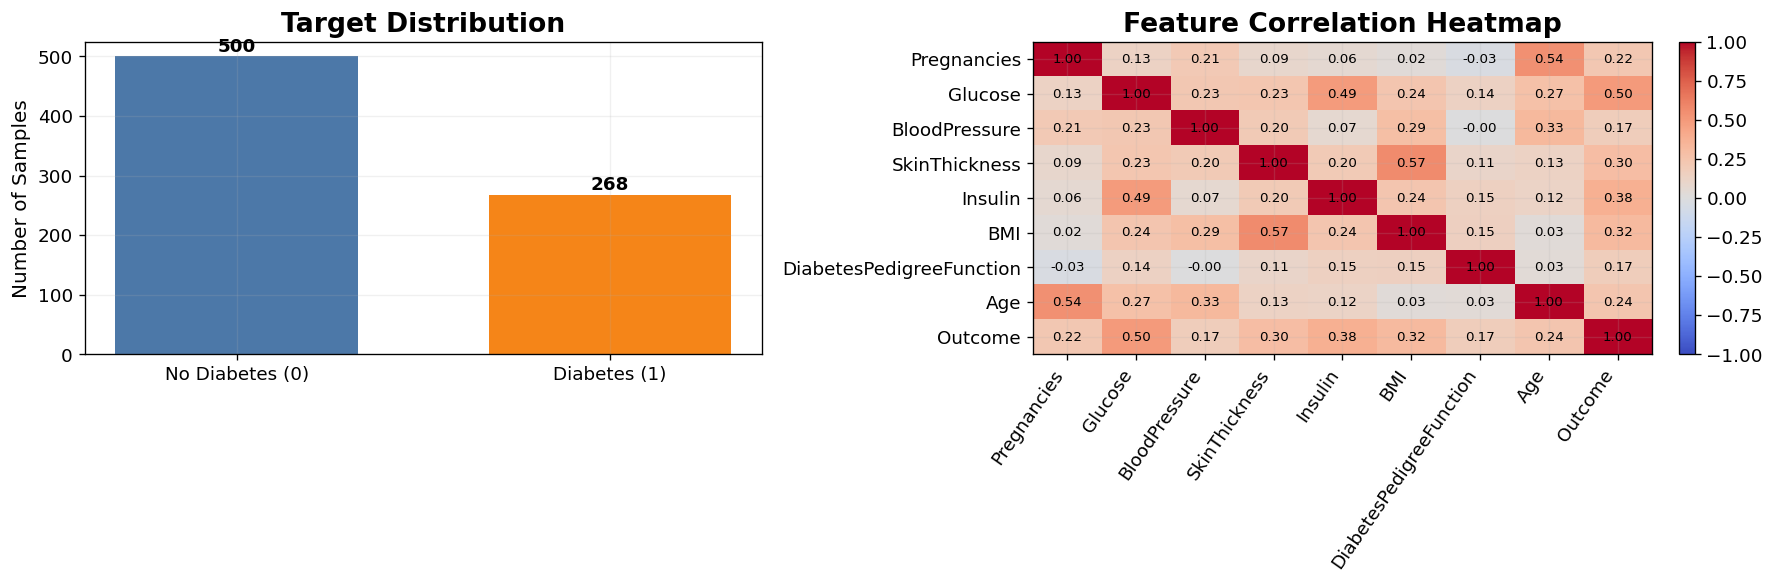

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df["Outcome"].value_counts().sort_index()
axes[0].bar(["No Diabetes (0)", "Diabetes (1)"], counts.values,
            color=["#4C78A8", "#F58518"], width=0.65)
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8, str(v), ha="center", fontweight="bold")

corr = df.corr(numeric_only=True)
im = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=55, ha="right")
axes[1].set_yticklabels(corr.columns)
axes[1].set_title("Feature Correlation Heatmap")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
feature_cols = [c for c in df.columns if c != "Outcome"]
X = df[feature_cols].copy()
y = df["Outcome"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (491, 8)
Validation: (123, 8)
Test: (154, 8)


In [6]:
def build_manual_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(1, activation="sigmoid")
    ])

    optimizer = keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

manual_model = build_manual_model(X_train_scaled.shape[1])
manual_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
manual_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

manual_start = time.perf_counter()

manual_history = manual_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=manual_callbacks,
    verbose=1
)

manual_time = time.perf_counter() - manual_start

print(f"Manual ANN training time: {manual_time:.2f} seconds")
print(f"Epochs actually used: {len(manual_history.history['loss'])}")

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.6049 - auc: 0.6002 - loss: 0.6493 - precision: 0.4017 - recall: 0.2749 - val_accuracy: 0.6667 - val_auc: 0.7042 - val_loss: 0.6063 - val_precision: 0.5625 - val_recall: 0.2093 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6843 - auc: 0.7620 - loss: 0.5765 - precision: 0.6143 - recall: 0.2515 - val_accuracy: 0.7154 - val_auc: 0.8179 - val_loss: 0.5460 - val_precision: 0.7000 - val_recall: 0.3256 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7271 - auc: 0.7978 - loss: 0.5423 - precision: 0.7229 - recall: 0.3509 - val_accuracy: 0.7480 - val_auc: 0.8594 - val_loss: 0.5012 - val_precision: 0.7727 - val_recall: 0.3953 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7373 - auc: 0.8285 - loss: 0.5154 - precision: 0.7442 - recall: 0.3743 - val_accuracy: 0.7886 - val_auc: 0.8826 - val_loss: 0.4686 - v

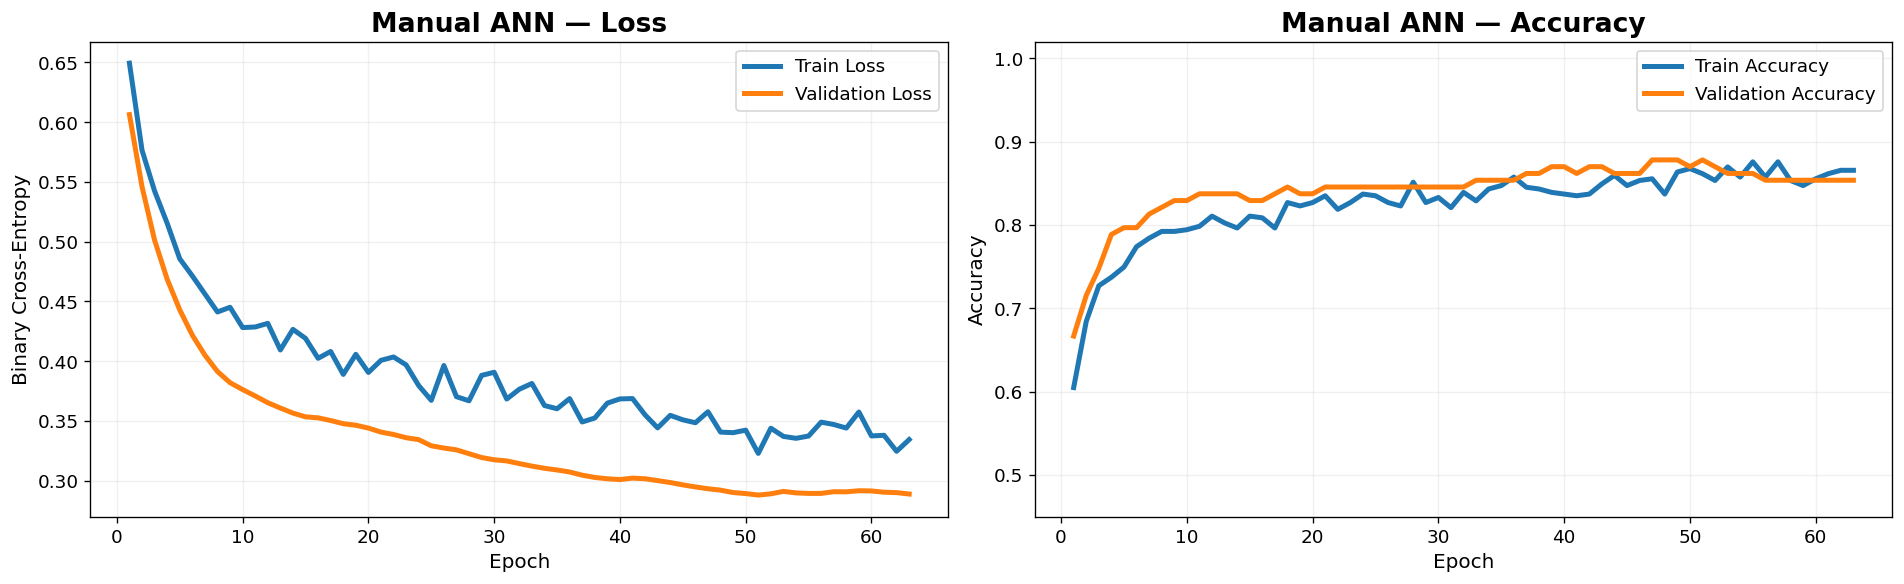

In [8]:
def plot_training_history(history, title_prefix):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(epochs, h["loss"], linewidth=3, label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], linewidth=3, label="Validation Loss")
    axes[0].set_title(f"{title_prefix} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy")
    axes[0].legend()

    axes[1].plot(epochs, h["accuracy"], linewidth=3, label="Train Accuracy")
    axes[1].plot(epochs, h["val_accuracy"], linewidth=3, label="Validation Accuracy")
    axes[1].set_title(f"{title_prefix} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.45, 1.02)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(manual_history, "Manual ANN")

In [9]:
def evaluate_model(model, X_eval, y_eval, name):
    probabilities = model.predict(X_eval, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "Recall": recall_score(y_eval, predictions, zero_division=0),
        "F1": f1_score(y_eval, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, probabilities)
    }
    return metrics, probabilities, predictions

manual_metrics, manual_probs, manual_preds = evaluate_model(
    manual_model, X_test_scaled, y_test, "Manual ANN"
)

print(classification_report(
    y_test, manual_preds,
    target_names=["No Diabetes", "Diabetes"],
    digits=4
))

display(pd.DataFrame([manual_metrics]).round(4))

              precision    recall  f1-score   support

 No Diabetes     0.8776    0.8600    0.8687       100
    Diabetes     0.7500    0.7778    0.7636        54

    accuracy                         0.8312       154
   macro avg     0.8138    0.8189    0.8162       154
weighted avg     0.8328    0.8312    0.8319       154



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Manual ANN,0.8312,0.75,0.7778,0.7636,0.8926


In [10]:
def build_tuned_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    num_layers = hp.Int("num_layers", min_value=1, max_value=3, step=1)
    activation = hp.Choice("activation", ["relu", "tanh"])

    for i in range(num_layers):
        units = hp.Int(
            f"units_{i}",
            min_value=16,
            max_value=128,
            step=16
        )
        dropout_rate = hp.Float(
            f"dropout_{i}",
            min_value=0.0,
            max_value=0.50,
            step=0.10
        )

        model.add(layers.Dense(units, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    learning_rate = hp.Choice(
        "learning_rate",
        [1e-2, 1e-3, 3e-4, 1e-4]
    )

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

tuner = kt.RandomSearch(
    build_tuned_model,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=20,
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_diabetes",
    project_name="manual_vs_tuner",
    seed=SEED
)

tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0003, 0.0001], 'ordered': True}


In [11]:
tuner_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]

tuner_start = time.perf_counter()

tuner.search(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=32,
    callbacks=tuner_callbacks,
    verbose=1
)

tuner_time = time.perf_counter() - tuner_start

print(f"Keras Tuner search time: {tuner_time:.2f} seconds")

Trial 20 Complete [00h 00m 24s]
val_auc: 0.9518895149230957

Best val_auc So Far: 0.9597384333610535
Total elapsed time: 00h 06m 39s
Keras Tuner search time: 398.63 seconds


In [12]:
tuner.results_summary(num_trials=10)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBEST HYPERPARAMETERS")
for key, value in best_hp.values.items():
    print(f"{key}: {value}")

Results summary
Results in keras_tuner_diabetes/manual_vs_tuner
Showing 10 best trials
Objective(name="val_auc", direction="max")

Trial 14 summary
Hyperparameters:
num_layers: 1
activation: tanh
units_0: 16
dropout_0: 0.2
learning_rate: 0.01
units_1: 16
dropout_1: 0.0
units_2: 32
dropout_2: 0.30000000000000004
Score: 0.9597384333610535

Trial 18 summary
Hyperparameters:
num_layers: 2
activation: tanh
units_0: 16
dropout_0: 0.1
learning_rate: 0.01
units_1: 16
dropout_1: 0.30000000000000004
units_2: 16
dropout_2: 0.1
Score: 0.9591570496559143

Trial 02 summary
Hyperparameters:
num_layers: 3
activation: relu
units_0: 128
dropout_0: 0.0
learning_rate: 0.0003
units_1: 32
dropout_1: 0.1
units_2: 16
dropout_2: 0.0
Score: 0.9571221470832825

Trial 11 summary
Hyperparameters:
num_layers: 2
activation: relu
units_0: 96
dropout_0: 0.2
learning_rate: 0.01
units_1: 32
dropout_1: 0.0
units_2: 112
dropout_2: 0.2
Score: 0.9537791609764099

Trial 03 summary
Hyperparameters:
num_layers: 2
activation: t

In [13]:
best_tuned_model = tuner.get_best_models(num_models=1)[0]

print("BEST TUNED MODEL")
best_tuned_model.summary()


BEST TUNED MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.8473 - auc: 0.9290 - loss: 0.3223 - precision: 0.8038 - recall: 0.7427 - val_accuracy: 0.8699 - val_auc: 0.9565 - val_loss: 0.2728 - val_precision: 0.7647 - val_recall: 0.9070 - learning_rate: 0.0100
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8534 - auc: 0.9224 - loss: 0.3363 - precision: 0.7964 - recall: 0.7778 - val_accuracy: 0.8780 - val_auc: 0.9567 - val_loss: 0.2678 - val_precision: 0.7692 - val_recall: 0.9302 - learning_rate: 0.0100
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8697 - auc: 0.9323 - loss: 0.3105 - precision: 0.8166 - recall: 0.8070 - val_accuracy: 0.8943 - val_auc: 0.9565 - val_loss: 0.2686 - val_precision: 0.7778 - val_recall: 0.9767 - learning_rate: 0.0100
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8697 - auc: 0.9356 - loss: 0.3047 - precision: 0.8023 - recall: 0.8304 - val_accuracy: 0.9024 - val_auc: 0.9594 - val_loss: 0.2653 - val_p

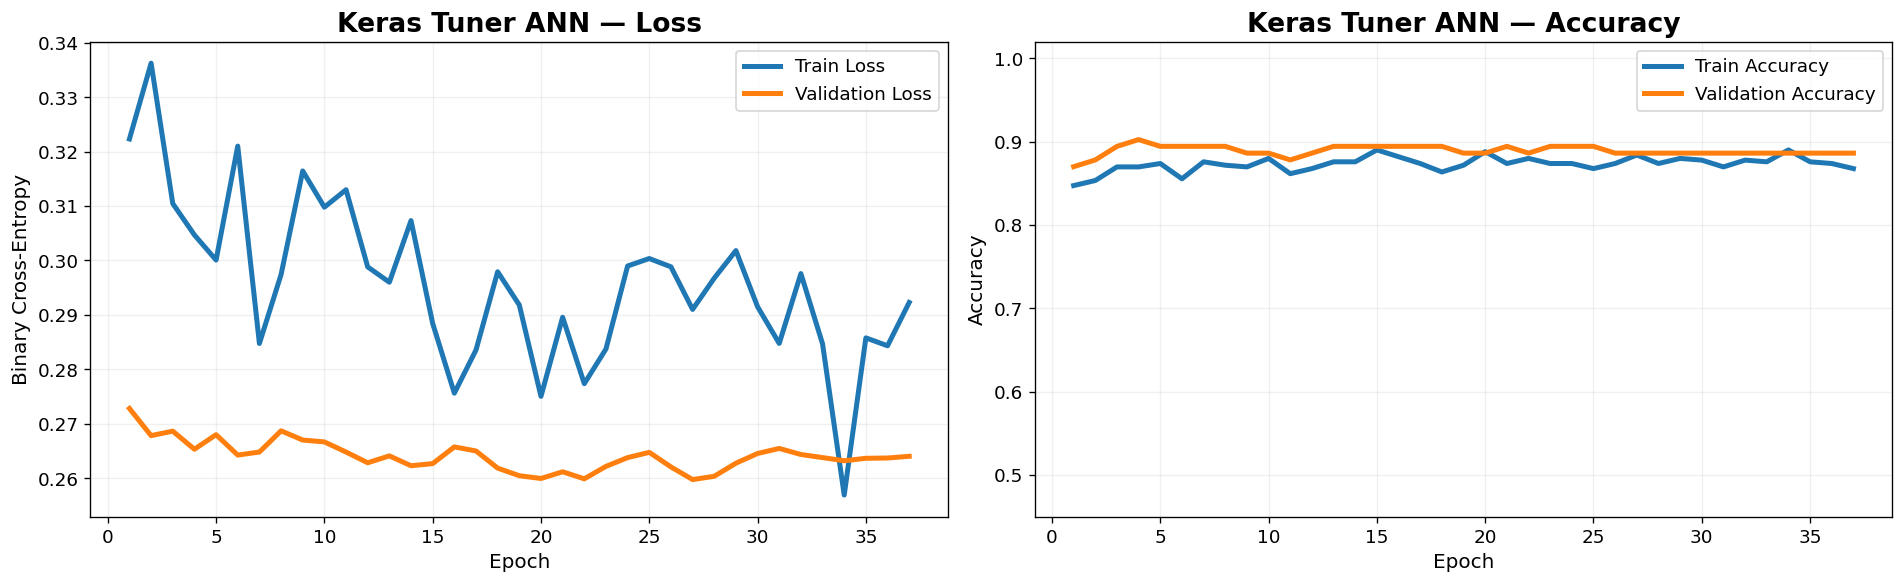

In [14]:
best_start = time.perf_counter()

best_history = best_tuned_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=tuner_callbacks,
    verbose=1
)

best_retrain_time = time.perf_counter() - best_start

print(f"Best tuned model retraining time: {best_retrain_time:.2f} seconds")
print(f"Epochs actually used: {len(best_history.history['loss'])}")

plot_training_history(best_history, "Keras Tuner ANN")

In [15]:
tuned_metrics, tuned_probs, tuned_preds = evaluate_model(
    best_tuned_model, X_test_scaled, y_test, "Keras Tuner ANN"
)

print(classification_report(
    y_test, tuned_preds,
    target_names=["No Diabetes", "Diabetes"],
    digits=4
))

display(pd.DataFrame([tuned_metrics]).round(4))


              precision    recall  f1-score   support

 No Diabetes     0.8800    0.8800    0.8800       100
    Diabetes     0.7778    0.7778    0.7778        54

    accuracy                         0.8442       154
   macro avg     0.8289    0.8289    0.8289       154
weighted avg     0.8442    0.8442    0.8442       154



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Keras Tuner ANN,0.8442,0.7778,0.7778,0.7778,0.9167


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Manual ANN,0.8312,0.7500,0.7778,0.7636,0.8926
Keras Tuner ANN,0.8442,0.7778,0.7778,0.7778,0.9167


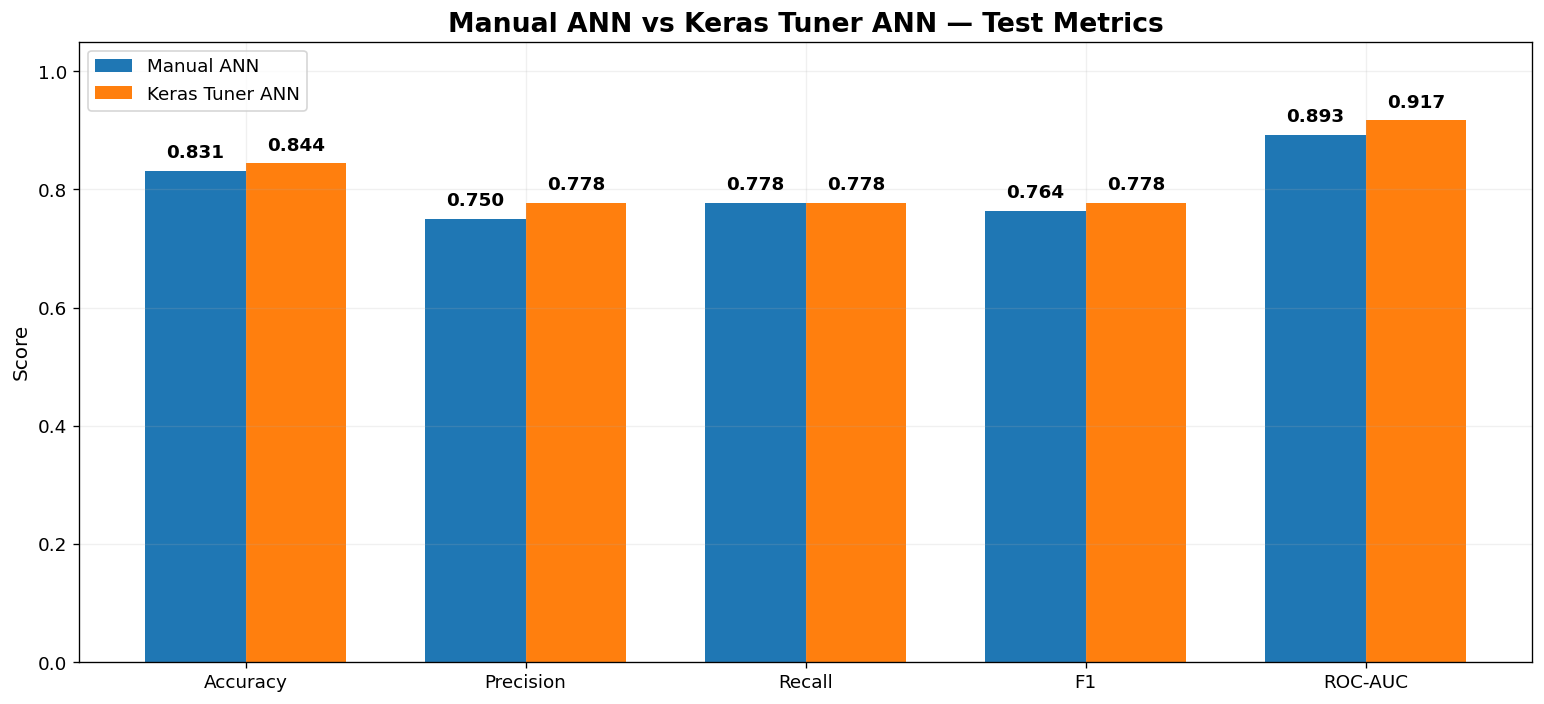

In [16]:
comparison_df = pd.DataFrame([manual_metrics, tuned_metrics]).set_index("Model")
display(comparison_df.round(4))

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(comparison_df.columns))
width = 0.36

bars1 = ax.bar(x - width/2, comparison_df.loc["Manual ANN"].values,
               width, label="Manual ANN")
bars2 = ax.bar(x + width/2, comparison_df.loc["Keras Tuner ANN"].values,
               width, label="Keras Tuner ANN")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.columns)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Manual ANN vs Keras Tuner ANN — Test Metrics")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.015,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

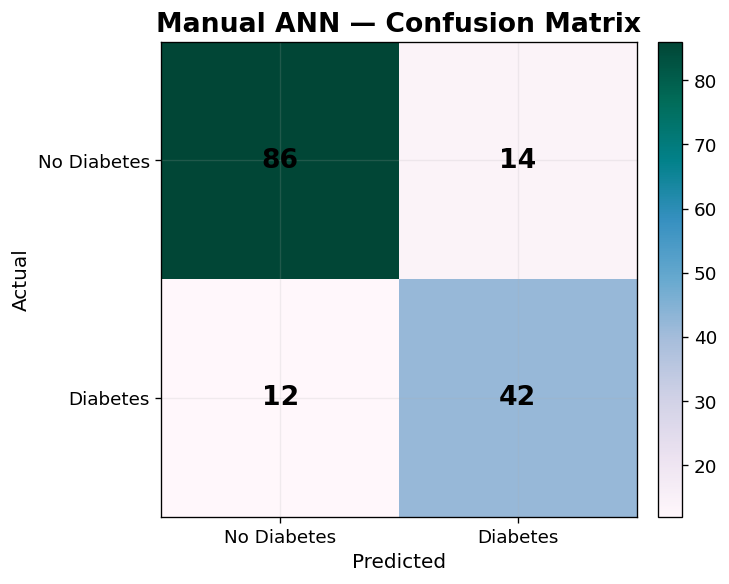

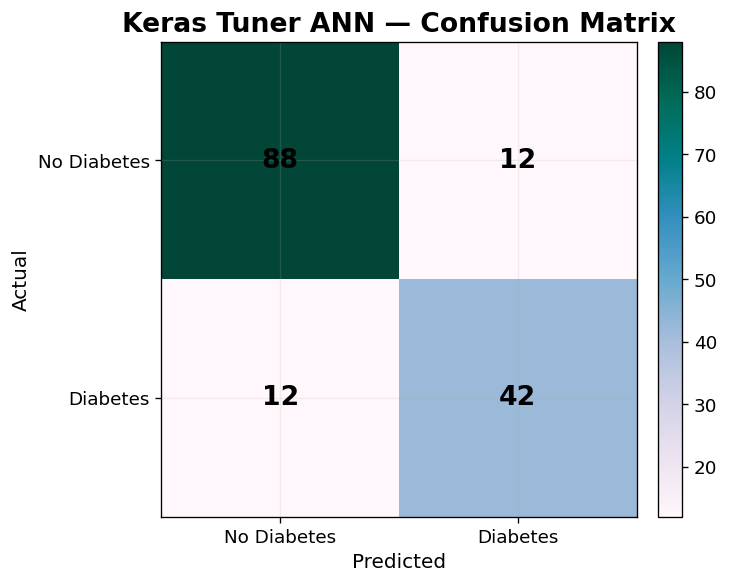

In [17]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="PuBuGn")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Diabetes", "Diabetes"])
    ax.set_yticklabels(["No Diabetes", "Diabetes"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    fontsize=16, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    confusion_matrix(y_test, manual_preds),
    "Manual ANN — Confusion Matrix"
)

plot_confusion_matrix(
    confusion_matrix(y_test, tuned_preds),
    "Keras Tuner ANN — Confusion Matrix"
)

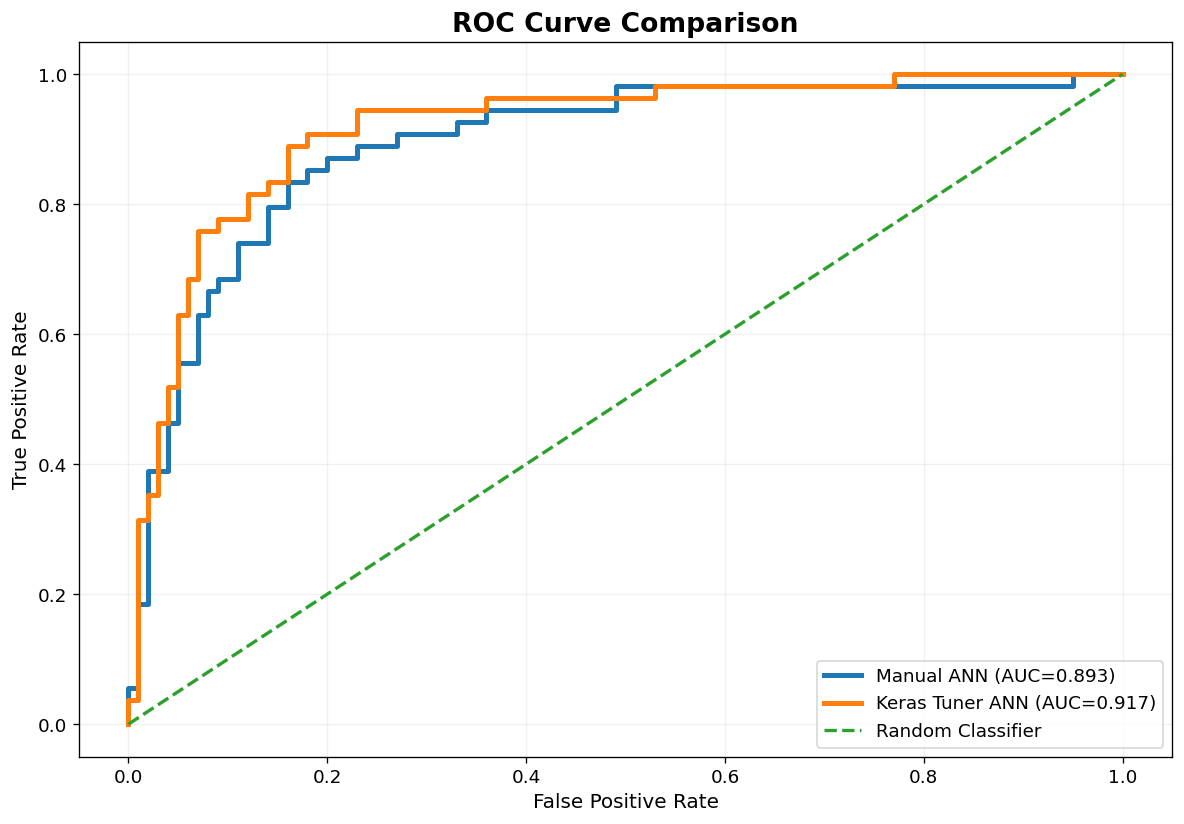

In [18]:
manual_fpr, manual_tpr, _ = roc_curve(y_test, manual_probs)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_probs)

plt.figure(figsize=(10, 7))
plt.plot(manual_fpr, manual_tpr, linewidth=3,
         label=f"Manual ANN (AUC={manual_metrics['ROC-AUC']:.3f})")
plt.plot(tuned_fpr, tuned_tpr, linewidth=3,
         label=f"Keras Tuner ANN (AUC={tuned_metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

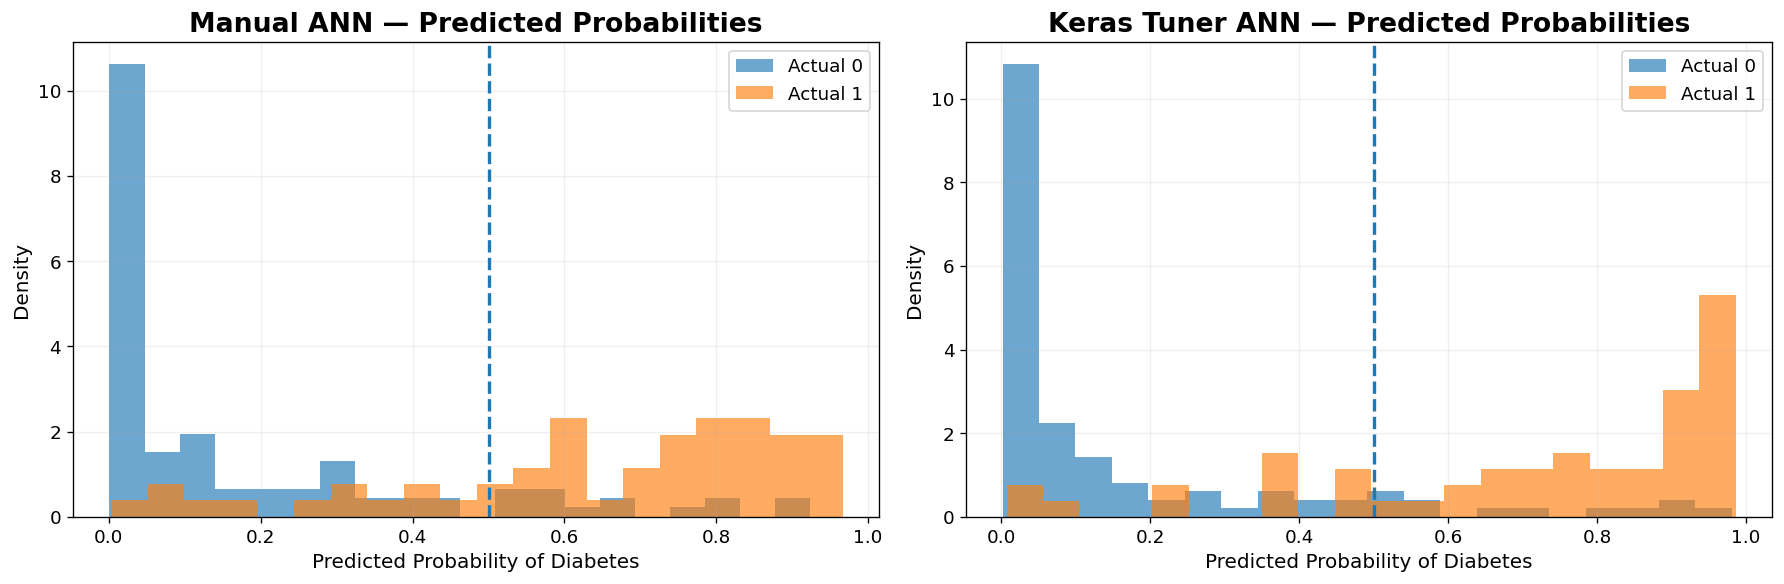

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(manual_probs[y_test.values == 0], bins=20, alpha=0.65,
             label="Actual 0", density=True)
axes[0].hist(manual_probs[y_test.values == 1], bins=20, alpha=0.65,
             label="Actual 1", density=True)
axes[0].axvline(0.5, linestyle="--", linewidth=2)
axes[0].set_title("Manual ANN — Predicted Probabilities")
axes[0].set_xlabel("Predicted Probability of Diabetes")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(tuned_probs[y_test.values == 0], bins=20, alpha=0.65,
             label="Actual 0", density=True)
axes[1].hist(tuned_probs[y_test.values == 1], bins=20, alpha=0.65,
             label="Actual 1", density=True)
axes[1].axvline(0.5, linestyle="--", linewidth=2)
axes[1].set_title("Keras Tuner ANN — Predicted Probabilities")
axes[1].set_xlabel("Predicted Probability of Diabetes")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


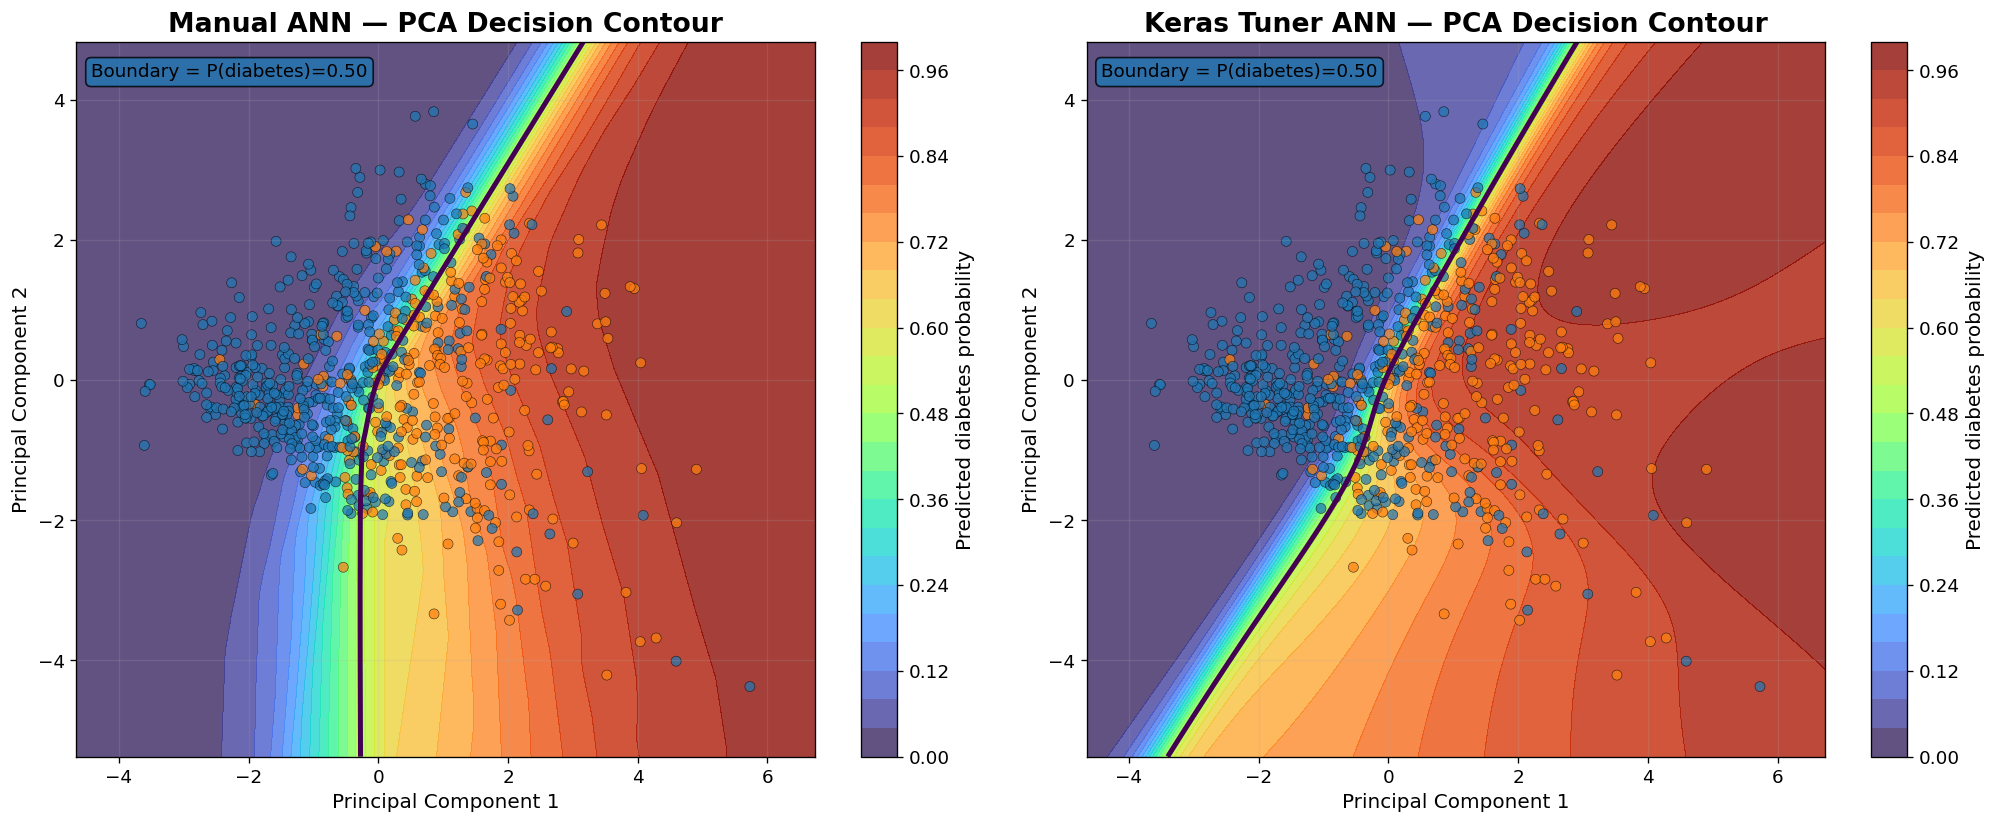

In [20]:
pca2 = PCA(n_components=2, random_state=SEED)
X_all_scaled = scaler.transform(X)

X_pca2 = pca2.fit_transform(X_all_scaled)

x_min, x_max = X_pca2[:, 0].min() - 1, X_pca2[:, 0].max() + 1
y_min, y_max = X_pca2[:, 1].min() - 1, X_pca2[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid_2d = np.c_[xx.ravel(), yy.ravel()]
X_grid_scaled = pca2.inverse_transform(grid_2d)

manual_grid_prob = manual_model.predict(X_grid_scaled, verbose=0).reshape(xx.shape)
tuned_grid_prob = best_tuned_model.predict(X_grid_scaled, verbose=0).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, probs, title in [
    (axes[0], manual_grid_prob, "Manual ANN — PCA Decision Contour"),
    (axes[1], tuned_grid_prob, "Keras Tuner ANN — PCA Decision Contour")
]:
    contour = ax.contourf(xx, yy, probs, levels=30, cmap="turbo", alpha=0.78)
    ax.contour(xx, yy, probs, levels=[0.5], linewidths=3)
    scatter = ax.scatter(
        X_pca2[:, 0], X_pca2[:, 1],
        c=y.values, cmap=ListedColormap(["#1f77b4", "#ff7f0e"]),
        edgecolor="black", linewidth=0.35, alpha=0.72, s=36
    )
    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.text(
        0.02, 0.97,
        "Boundary = P(diabetes)=0.50",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.80)
    )
    fig.colorbar(contour, ax=ax, label="Predicted diabetes probability")

plt.tight_layout()
plt.show()

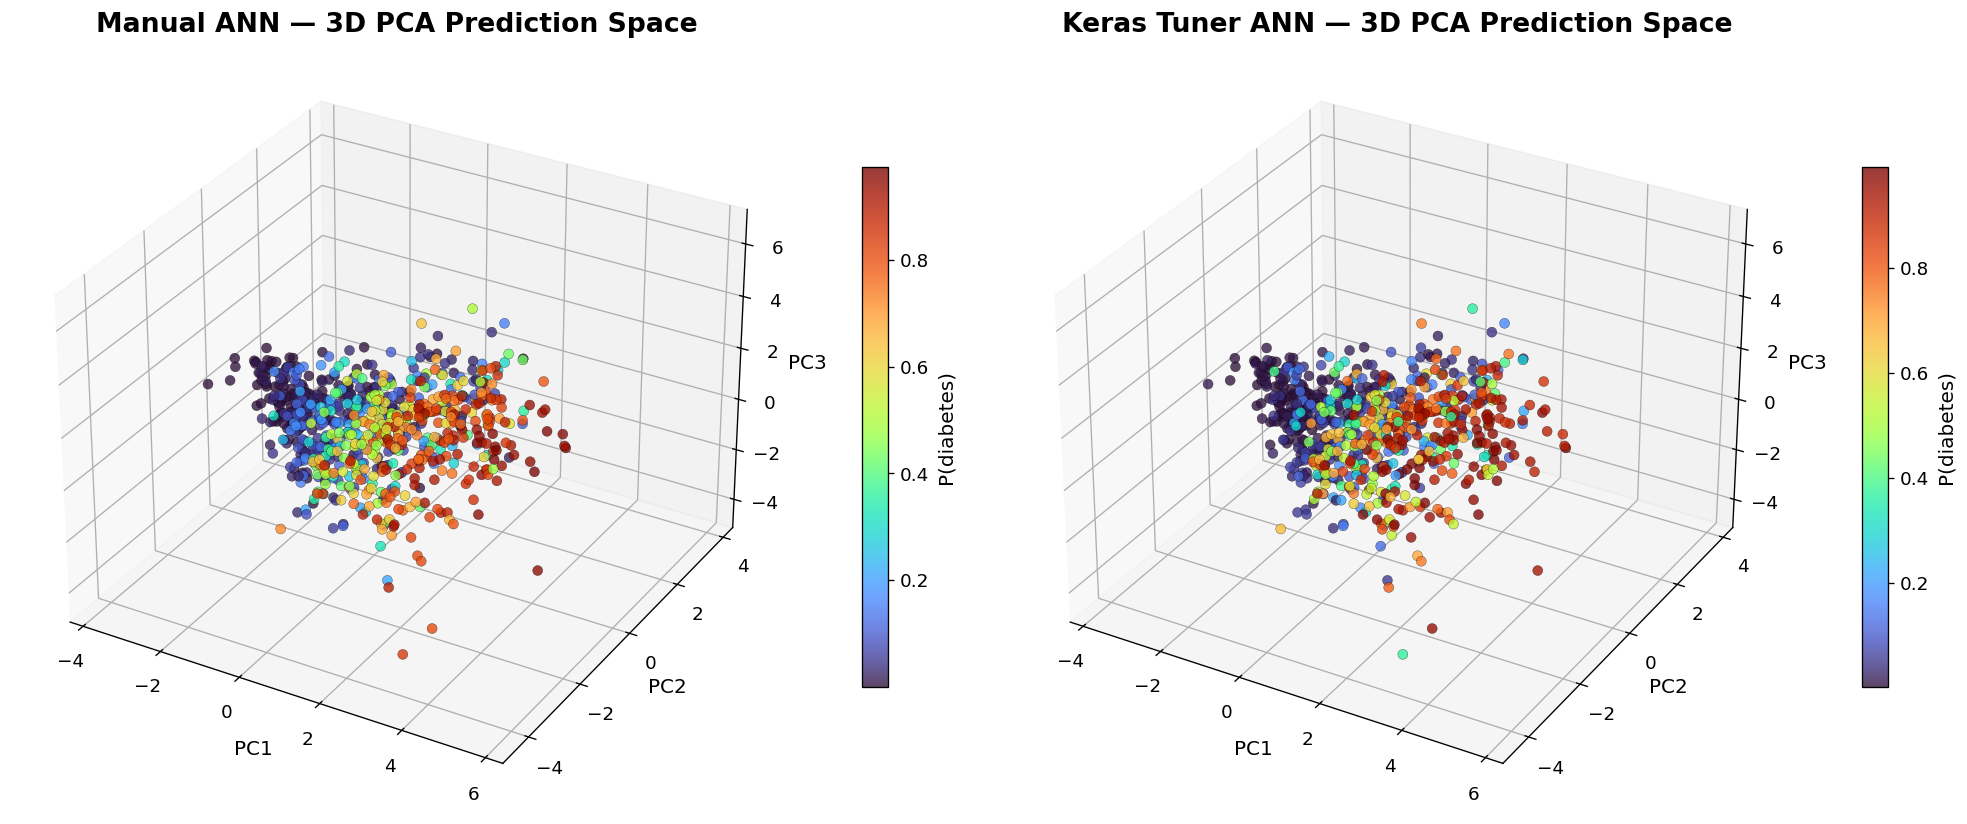

In [21]:
pca3 = PCA(n_components=3, random_state=SEED)
X_pca3 = pca3.fit_transform(X_all_scaled)

manual_all_prob = manual_model.predict(X_all_scaled, verbose=0).ravel()
tuned_all_prob = best_tuned_model.predict(X_all_scaled, verbose=0).ravel()

fig = plt.figure(figsize=(17, 7))

ax1 = fig.add_subplot(121, projection="3d")
p1 = ax1.scatter(
    X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
    c=manual_all_prob, cmap="turbo",
    s=36, alpha=0.78, edgecolor="black", linewidth=0.2
)
ax1.set_title("Manual ANN — 3D PCA Prediction Space")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")
fig.colorbar(p1, ax=ax1, shrink=0.65, pad=0.08, label="P(diabetes)")

ax2 = fig.add_subplot(122, projection="3d")
p2 = ax2.scatter(
    X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
    c=tuned_all_prob, cmap="turbo",
    s=36, alpha=0.78, edgecolor="black", linewidth=0.2
)
ax2.set_title("Keras Tuner ANN — 3D PCA Prediction Space")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
fig.colorbar(p2, ax=ax2, shrink=0.65, pad=0.08, label="P(diabetes)")

plt.tight_layout()
plt.show()

,trial_id,score,num_layers,activation,units_0,dropout_0,learning_rate,units_1,dropout_1,units_2,dropout_2
14,14,0.9597,1,tanh,16,0.2,0.0100,16,0.0,32.0,0.3
18,18,0.9592,2,tanh,16,0.1,0.0100,16,0.3,16.0,0.1
2,02,0.9571,3,relu,128,0.0,0.0003,32,0.1,16.0,0.0
11,11,0.9538,2,relu,96,0.2,0.0100,32,0.0,112.0,0.2
3,03,0.9528,2,tanh,64,0.2,0.0010,16,0.0,96.0,0.3
12,12,0.9526,2,tanh,64,0.4,0.0100,80,0.2,16.0,0.4
19,19,0.9519,2,relu,80,0.1,0.0003,64,0.2,64.0,0.0
1,01,0.9512,2,tanh,16,0.2,0.0100,128,0.3,NaN,NaN
16,16,0.9512,3,tanh,32,0.2,0.0010,16,0.1,128.0,0.1
13,13,0.9509,3,tanh,128,0.1,0.0003,64,0.3,96.0,0.1


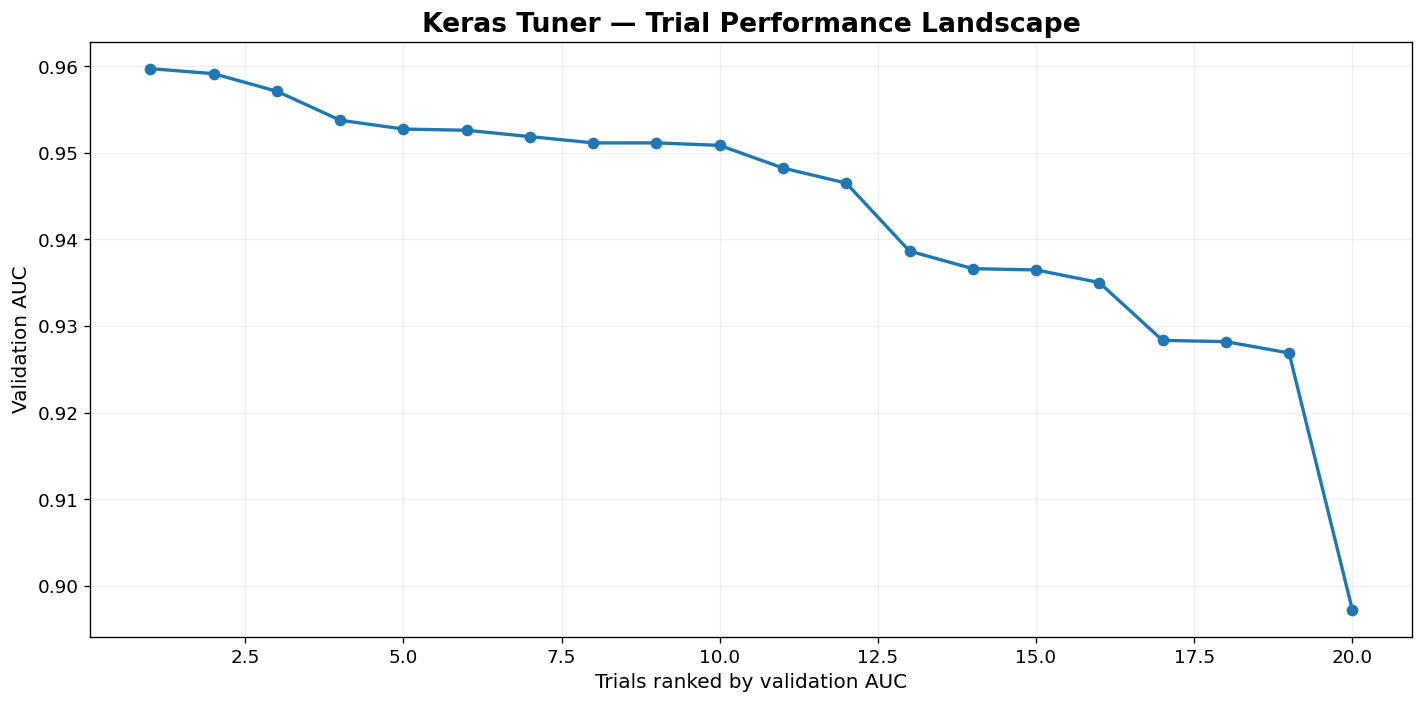

In [22]:
trials = tuner.oracle.trials
trial_rows = []

for trial_id, trial in trials.items():
    row = {
        "trial_id": trial_id,
        "score": trial.score
    }
    row.update(trial.hyperparameters.values)
    trial_rows.append(row)

trials_df = pd.DataFrame(trial_rows).sort_values("score", ascending=False)

display(trials_df.head(10).round(4))

plt.figure(figsize=(12, 6))
plt.plot(
    np.arange(1, len(trials_df) + 1),
    trials_df["score"].values,
    marker="o",
    linewidth=2
)
plt.xlabel("Trials ranked by validation AUC")
plt.ylabel("Validation AUC")
plt.title("Keras Tuner — Trial Performance Landscape")
plt.tight_layout()
plt.show()

In [23]:
summary = pd.DataFrame({
    "Manual ANN": [
        "Fixed by human",
        "32 → 16 hidden units",
        "Adam, lr=0.001",
        "2 hidden layers",
        "Dropout 0.20 / 0.10",
        "1 trained configuration"
    ],
    "Keras Tuner ANN": [
        "Selected by search",
        "16–128 units per hidden layer",
        "Several learning rates",
        "1–3 hidden layers",
        "0.00–0.50 dropout",
        f"{len(trials_df)} trials searched"
    ]
}, index=[
    "Architecture decision",
    "Units",
    "Learning rate",
    "Hidden layers",
    "Dropout",
    "Search breadth"
])

display(summary)

,Manual ANN,Keras Tuner ANN
Architecture decision,Fixed by human,Selected by search
Units,32 → 16 hidden units,16–128 units per hidden layer
Learning rate,"Adam, lr=0.001",Several learning rates
Hidden layers,2 hidden layers,1–3 hidden layers
Dropout,Dropout 0.20 / 0.10,0.00–0.50 dropout
Search breadth,1 trained configuration,20 trials searched


In [24]:
best_trial = trials_df.iloc[0]

final_comparison = comparison_df.copy()
final_comparison["Training/Search Time (sec)"] = [
    manual_time,
    tuner_time + best_retrain_time
]

print("=== FINAL COMPARISON ===")
display(final_comparison.round(4))

print("\nBEST TUNER CONFIGURATION:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

print("\nManual ANN parameters were selected explicitly by the programmer.")
print("Keras Tuner parameters were selected through the defined search space.")

=== FINAL COMPARISON ===


,Accuracy,Precision,Recall,F1,ROC-AUC,Training/Search Time (sec)
Model,,,,,,
Manual ANN,0.8312,0.7500,0.7778,0.7636,0.8926,30.2787
Keras Tuner ANN,0.8442,0.7778,0.7778,0.7778,0.9167,414.6539



BEST TUNER CONFIGURATION:
num_layers: 1
activation: tanh
units_0: 16
dropout_0: 0.2
learning_rate: 0.01
units_1: 16
dropout_1: 0.0
units_2: 32
dropout_2: 0.30000000000000004

Manual ANN parameters were selected explicitly by the programmer.
Keras Tuner parameters were selected through the defined search space.


In [25]:
loss_values = best_history.history["loss"]
val_loss_values = best_history.history["val_loss"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(1, len(loss_values))
ax.set_ylim(0, max(max(loss_values), max(val_loss_values)) * 1.08)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Keras Tuner ANN — Training Progress Animation")

train_line, = ax.plot([], [], linewidth=3, label="Train Loss")
val_line, = ax.plot([], [], linewidth=3, label="Validation Loss")
ax.legend()

def update(frame):
    x = np.arange(1, frame + 1)
    train_line.set_data(x, loss_values[:frame])
    val_line.set_data(x, val_loss_values[:frame])
    return train_line, val_line

animation = FuncAnimation(
    fig, update,
    frames=len(loss_values),
    interval=100,
    blit=True,
    repeat=False
)

plt.close(fig)
HTML(animation.to_jshtml())